# Heart Attack Disease Detection - Data Exploration

This notebook contains the EDA process for this project. Here you will find different features and preprocess methods for the data to use in this project.

The dataset used was taken from Kaggle, you can find it here: https://www.kaggle.com/datasets/jocelyndumlao/cardiovascular-disease-dataset/data

The attributes included in the dataset are:
* **Patient ID** - Unique identifier for each patient

* **Age** - Age of the patient

* **Gender** - Gender of the patient (0= female, 1 = male)

* **Chest Pain Type** - 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic

* **Resting Blood Pressure** - Blood pressure of the patient (in mm HG)

* **Serum Cholesterol** - Cholesterol in blood (in mg/dl)

* **Fasting Blood Sugar** - Whether the patient has > 120 mg/dl (0 = false, 1 = true)

* **Resting Electrocardiogram Results** - 0 = normal, 1 = having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria

* **Maximun Heart Rate** - Maximun heart rate of the patient (71-202)

* **Exercise induced angina** - 1 =  Yes, 0 = No

* **Oldpeak =ST** - 0-6.2

* **Slope of the peak exercise ST segment** - 1 = upsloping, 2 = flat, 3 = downsloping

* **Number of major vessels** - 0, 1, 2, 3

* **Classification** - 0 = Absence of Heart Disease, 1 = Presence of Heart Disease

In [19]:
import sys
sys.path.append("../src")

import data.make_dataset as data
import visualizations.exploratory as eda

import importlib
importlib.reload(data)
importlib.reload(eda)

<module 'visualizations.exploratory' from 'c:\\Users\\isaac\\Documents\\GitHub\\heart-attack-risk-detection\\notebooks\\../src\\visualizations\\exploratory.py'>

## Load Raw Data

In [2]:
# Load the raw data
df = data.load_dataset("../data/raw/dataset.csv")
df

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,9949544,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,9953423,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,9965859,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,9988507,45,1,1,186,417,0,1,117,1,5.9,3,2,1


## Exploratoy Data Analysis

In [3]:
# Displays data features (columns)
df.columns

Index(['patientid', 'age', 'gender', 'chestpain', 'restingBP',
       'serumcholestrol', 'fastingbloodsugar', 'restingrelectro',
       'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels',
       'target'],
      dtype='object')

Let's verify whether there are missing values.

In [4]:
# Verify null values
df.isna().sum()

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

Let's verify whether there are non-numeric columns.

In [5]:
# Verify datatypes
df.dtypes

patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object

We can drop the PatientID columns, since it is not important for the analysis.

Now, let's see how many records are for each target class.

In [7]:
# Verify total values for each target class
df["target"].value_counts()

target
1    580
0    420
Name: count, dtype: int64

Here, we can see the data is a little unbalanced.

In [8]:
# Show some statistical information about the data
df.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


## Graphical comparisons

First, let's check the age distribution by heart attack disease

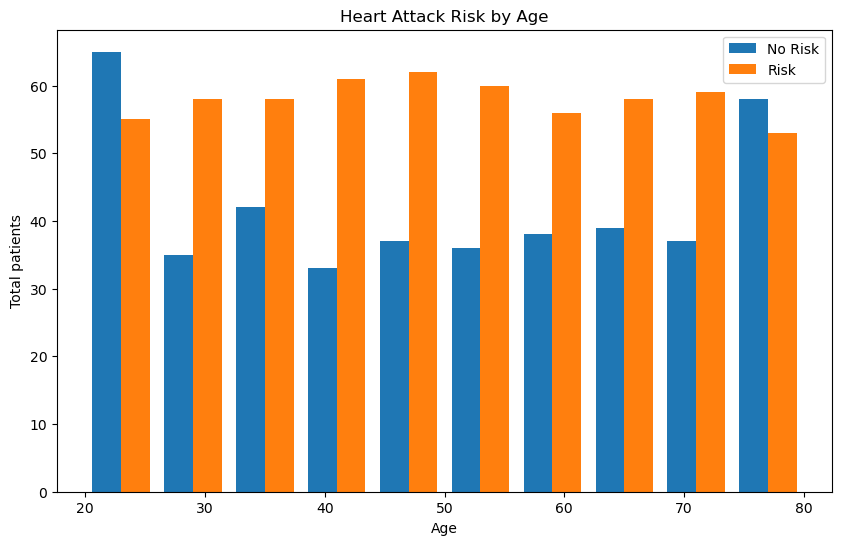

In [9]:
eda.plot_age_hist(df.age[df["target"] == 0], df.age[df["target"] == 1])

Now, let's compare gender with Heart Attack Risk

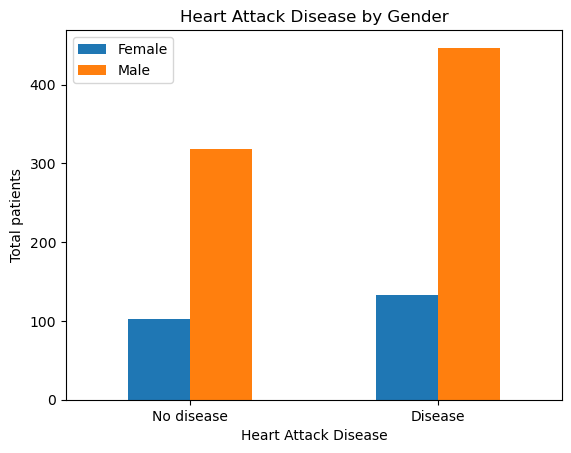

In [17]:
eda.plot_disease_vs_gender(df)

Now, let's compare the Maximun Heart Rate to the cholesterol levels

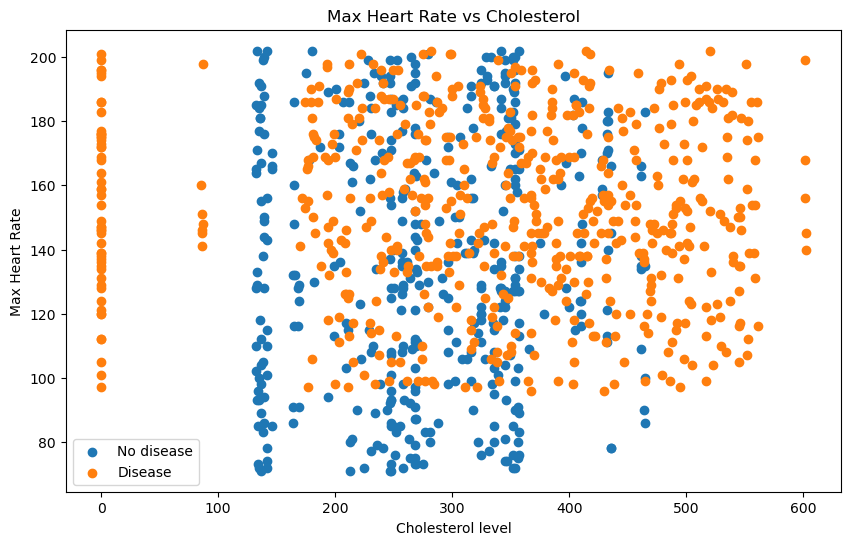

In [20]:
eda.plot_hr_vs_chol(df)

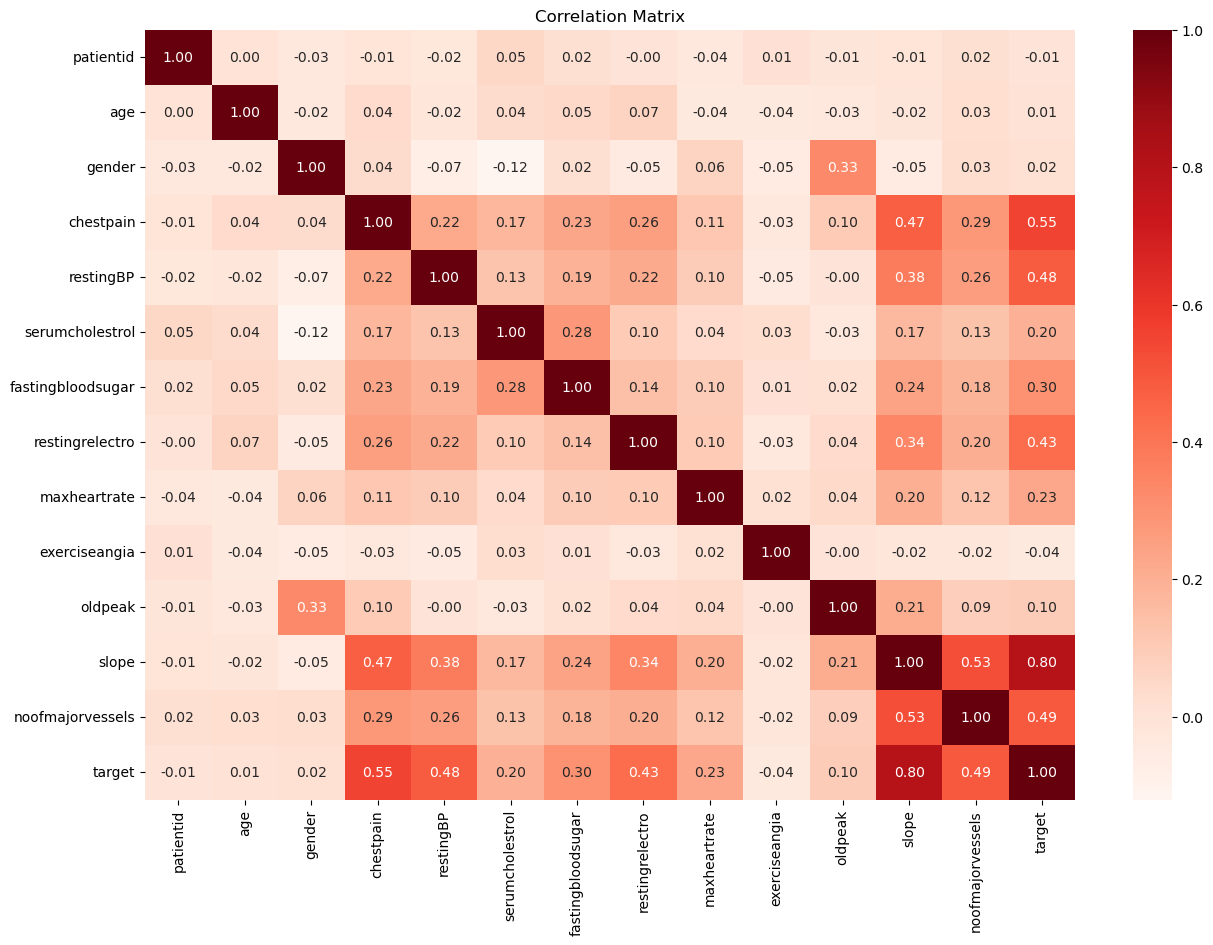

In [22]:
eda.plot_corr_matrix(df)